In [7]:
import pandas as pd
import os
import re
from pathlib import Path

# Load the Excel file
file_path = r"C:\Users\kamalesh\OneDrive\Articles\Review Article\4. ExplainableAI\RAW\1. A Final database 03052026.xlsx"
df = pd.read_excel(file_path)

# Display first few rows to understand data
print("Original data shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

# Create output folder
output_folder = r"codes\Keywords"
os.makedirs(output_folder, exist_ok=True)
print(f"\nOutput folder created at: {output_folder}")

Original data shape: (56, 7)

First few rows:
                                           Inclusion  \
0  A lightweight and explainable CNN model for em...   
1  A lightweight and generalizable deep learning ...   
2  A Multitask Learning-Based Vision Transformer ...   
3  Advanced neural network architectures for toma...   
4  AI-driven drone technology and computer vision...   

                                     Author Keywords  \
0  Plant disease recognition, Deep learning, Tran...   
1  Rice leaf disease detection, Lightweight deep ...   
2  Plant disease · Classification · Localization ...   
3  Hybrid model · Grad-CAM · LIME techniques · Ar...   
4  Precision Agriculture, Deep Learning, IoT Inte...   

                                             Authors  Year Publisher  \
0  Chiranjit PalSwastik KarmakarImon MukherjeePar...  2025         0   
1  Chong ZhangXiaoxi HaoJianan LiangLili LiWenwei Li  2025         0   
2         S. HemalathaJai Jaganath Babu Jayachandran  2024      

In [8]:
# Preprocessing: Convert to lowercase
df['Author Keywords'] = df['Author Keywords'].astype(str).str.lower()

# Function to extract keywords with flexible separation handling
def extract_keywords(keyword_string):
    """
    Extract keywords handling multiple separators and special cases
    """
    if pd.isna(keyword_string) or keyword_string == '0' or keyword_string.strip() == '':
        return []
    
    # Replace common separators with comma
    keyword_string = str(keyword_string)
    keyword_string = re.sub(r'[;|/]', ',', keyword_string)
    
    # Split by comma
    keywords = keyword_string.split(',')
    
    # Clean each keyword: strip whitespace, remove special chars, convert to lowercase
    cleaned_keywords = []
    for kw in keywords:
        # Strip whitespace
        kw = kw.strip()
        # Remove special characters but keep spaces and hyphens within keywords
        kw = re.sub(r'[^\w\s\-]', '', kw)
        # Remove extra spaces
        kw = re.sub(r'\s+', ' ', kw).strip()
        
        if kw and len(kw) > 1:  # Only keep non-empty keywords with more than 1 character
            cleaned_keywords.append(kw)
    
    return cleaned_keywords

# Extract keywords for each row
df['extracted_keywords'] = df['Author Keywords'].apply(extract_keywords)

# Create a new dataframe with one keyword per row
keyword_records = []
for idx, row in df.iterrows():
    keywords_list = row['extracted_keywords']
    for keyword in keywords_list:
        keyword_records.append({
            'article_title': row['Inclusion'],
            'extracted_keyword': keyword,
            'final_keyword': ''  # Empty column for manual mapping
        })

# Create keywords dataframe
keywords_df = pd.DataFrame(keyword_records)

# Save to CSV
csv_path = os.path.join(output_folder, 'raw_keywords.csv')
keywords_df.to_csv(csv_path, index=False, encoding='utf-8')

print(f"Keywords extracted: {len(keywords_df)} total keywords")
print(f"Unique keywords: {keywords_df['extracted_keyword'].nunique()}")
print(f"\nCSV file saved at: {csv_path}")
print("\nFirst few extracted keywords:")
print(keywords_df.head(10))

Keywords extracted: 312 total keywords
Unique keywords: 191

CSV file saved at: codes\Keywords\raw_keywords.csv

First few extracted keywords:
                                       article_title  \
0  A lightweight and explainable CNN model for em...   
1  A lightweight and explainable CNN model for em...   
2  A lightweight and explainable CNN model for em...   
3  A lightweight and explainable CNN model for em...   
4  A lightweight and generalizable deep learning ...   
5  A lightweight and generalizable deep learning ...   
6  A lightweight and generalizable deep learning ...   
7  A lightweight and generalizable deep learning ...   
8  A lightweight and generalizable deep learning ...   
9  A Multitask Learning-Based Vision Transformer ...   

                                   extracted_keyword final_keyword  
0                          plant disease recognition                
1                                      deep learning                
2                                

Total unique keywords: 191

Top 20 keywords by frequency:
deep learning                          24
explainable ai                         18
transfer learning                       8
precision agriculture                   8
explainable artificial intelligence     7
grad-cam                                6
computer vision                         6
lime                                    5
convolutional neural networks           5
disease detection                       4
plant diseases                          4
classification                          3
feature selection                       3
machine learning                        3
vision transformers                     3
feature extraction                      3
convolutional neural network            3
vision transformer                      3
xai                                     3
agriculture                             3
Name: count, dtype: int64

Keyword cloud saved at: codes\Keywords\keyword_cloud.png


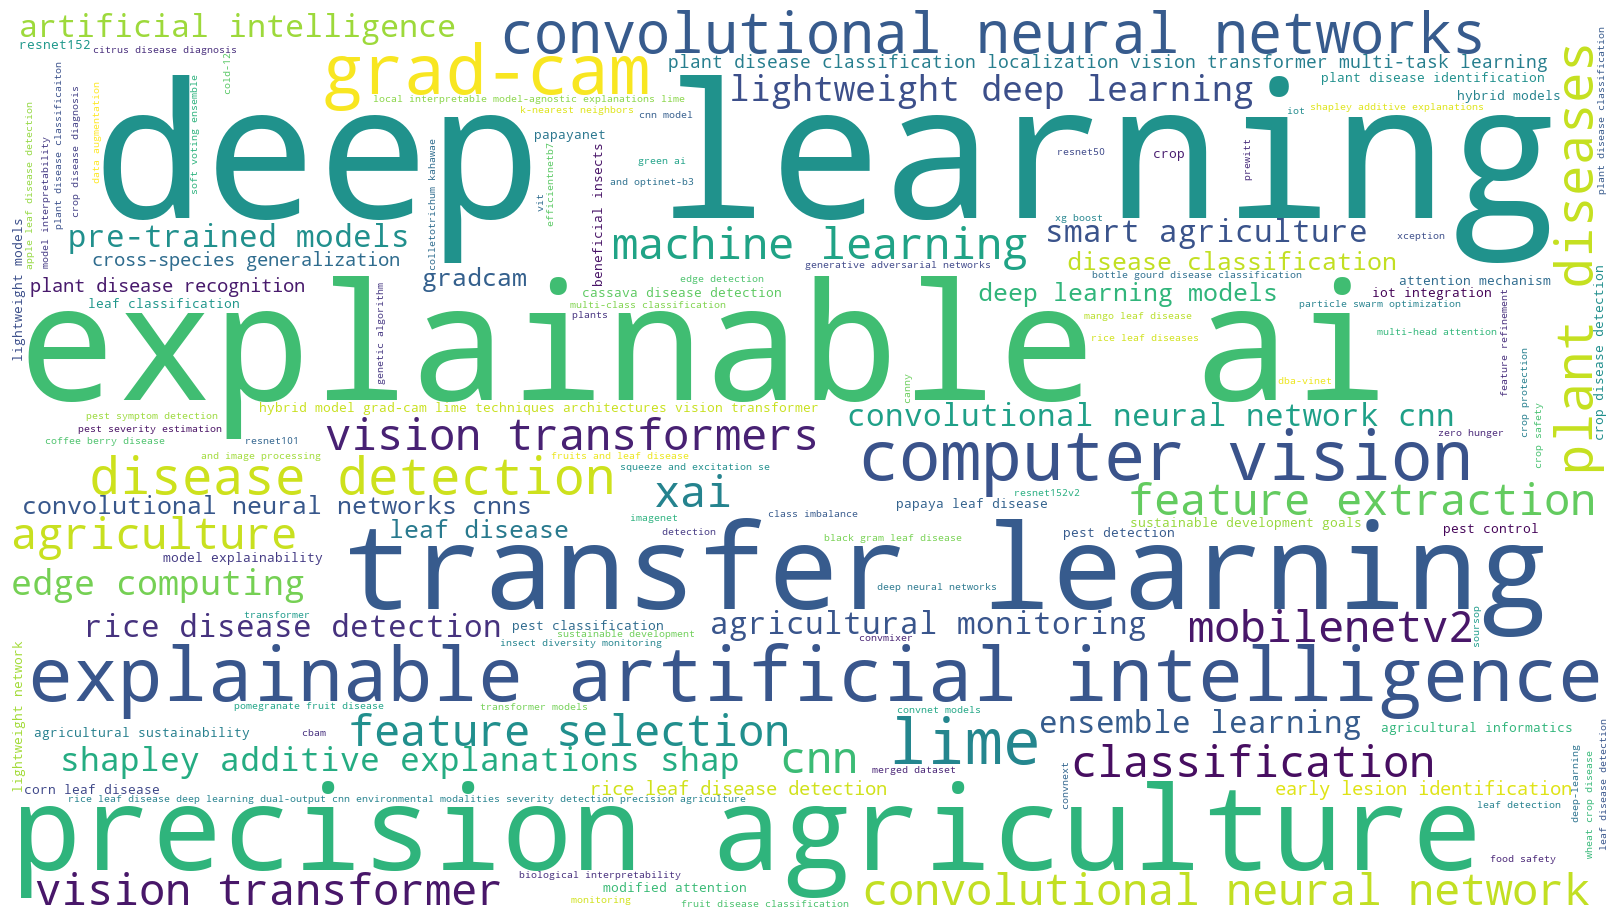


Keyword cloud visualization complete!
Total keywords visualized: 191


In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Calculate keyword frequencies
keyword_freq = df['extracted_keywords'].apply(pd.Series).stack().value_counts()

# Convert to dictionary for wordcloud
keyword_freq_dict = keyword_freq.to_dict()

print(f"Total unique keywords: {len(keyword_freq_dict)}")
print("\nTop 20 keywords by frequency:")
print(keyword_freq.head(20))

# Create a custom color function for better visualization
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    """Color function that assigns colors based on word frequency"""
    return plt.cm.viridis(np.random.random())

# Generate wordcloud with rectangular layout
wordcloud = WordCloud(
    width=1600, 
    height=900,
    background_color='white',
    colormap='viridis',
    prefer_horizontal=0.7,
    max_words=None,  # Show all keywords
    relative_scaling=0.5,
    min_font_size=10,
    font_path=None  # Use default font
).generate_from_frequencies(keyword_freq_dict)

# Create figure with wordcloud
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
plt.tight_layout(pad=0)

# Save the wordcloud image
image_path = os.path.join(output_folder, 'keyword_cloud.png')
plt.savefig(image_path, bbox_inches='tight', dpi=300, facecolor='white')
print(f"\nKeyword cloud saved at: {image_path}")

plt.show()

print(f"\nKeyword cloud visualization complete!")
print(f"Total keywords visualized: {len(keyword_freq_dict)}")